In [9]:

import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load dataset menggunakan pandas
df = pd.read_csv('data_pertanian.csv',sep=";")
df_raw = df.copy() # Simpan salinan untuk perbandingan

# 2. Identifikasi dan mengatasi nilai yang hilang
# Mengecek jumlah nilai yang hilang
missing_info = df.isnull().sum()
# Berdasarkan dataset ini, tidak ada nilai kosong (0 missing values).
# Jika ada, metode yang digunakan adalah menghapus baris tersebut adalah:
df_cleaned = df.dropna()

# 3. Normalisasi fitur numerik
# Memilih kolom numerik: suhu, kelembaban, curah_hujan, luas_lahan, hasil_panen
numeric_cols = ['suhu', 'kelembaban', 'curah_hujan', 'luas_lahan', 'hasil_panen']
scaler = StandardScaler()
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])

# 4. Perbandingan Statistik Sebelum dan Sesudah Preprocessing ---
print("\n======================================================")
print(" PERBANDINGAN STATISTIK SEBELUM DAN SESUDAH PREPROCESSING")
print("======================================================")

df_raw_stats_summary = df_raw[numeric_cols].agg(['mean', 'std', 'min', 'max'])
df_cleaned_stats_summary = df_cleaned[numeric_cols].agg(['mean', 'std', 'min', 'max'])

df_raw_stats_summary.columns = [col + '_raw' for col in df_raw_stats_summary.columns]
df_cleaned_stats_summary.columns = [col + '_preprocessed' for col in df_cleaned_stats_summary.columns]

comparison_df = pd.concat([df_raw_stats_summary, df_cleaned_stats_summary], axis=1)

display(comparison_df)



 PERBANDINGAN STATISTIK SEBELUM DAN SESUDAH PREPROCESSING


,suhu_raw,kelembaban_raw,curah_hujan_raw,luas_lahan_raw,hasil_panen_raw,suhu_preprocessed,kelembaban_preprocessed,curah_hujan_preprocessed,luas_lahan_preprocessed,hasil_panen_preprocessed
mean,27.052711,77.424110,155.280399,2.710170,44.626107,1.854072e-15,7.249756e-16,-2.509104e-16,-3.197442e-16,-3.341771e-16
std,4.462341,10.258894,88.027874,1.320535,8.594415,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,20.082832,60.243325,1.518475,0.564771,26.854072,-1.569802e+00,-1.683158e+00,-1.755541e+00,-1.632829e+00,-2.078276e+00
max,34.803304,94.497766,297.016155,4.957273,61.551666,1.745639e+00,1.672663e+00,1.618235e+00,1.710234e+00,1.979289e+00


In [10]:
# Soal Nomor 3
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Memuat data
X = df.drop(columns=['kategori_hasil'])
y = df['kategori_hasil']

# 1. Membagi data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Algoritma Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 3. Evaluasi model
y_pred = clf.predict(X_test)
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100}%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Akurasi: 100.0%
Confusion Matrix:
 [[8 0 0]
 [0 4 0]
 [0 0 8]]


3.4. Berdasarkan hasil evaluasi di atas, evaluasinya mencakup:
1. Akurasi Sempurna (100%): Model dapat secara tepat memprediksi seluruh data uji (20 sampel) tanpa menunjukkan adanya kesalahan. Ini berarti pola hubungan antara variabel lingkungan (suhu, kelembaban, dll.) dengan kategori hasil sangat kuat dan jelas dalam data tsb.
2. Analisis Confusion Matrix: Kelas 'rendah': 8 sampel diprediksi dengan benar.Kelas 'sedang': 4 sampel diprediksi dengan benar.Kelas 'tinggi': 8 sampel diprediksi dengan benar.Tidak terdapat nilai di luar diagonal utama, yang berarti tidak ada False Positive maupun False Negative.
3. Karakteristik Decision Tree: Algoritma ini sangat baik dalam menangani data yang memiliki batas keputusan (decision boundary) yang tegas. Dalam kasus pertanian, ini berarti model berhasil menemukan ambang batas nilai (misal: "Jika curah hujan > X dan suhu < Y maka hasil tinggi") yang sangat konsisten.

In [11]:
# Soal Nomor 4

# 1. Menampilkan Statistik Deskriptif
print("==================================================")
print("             STATISTIK DESKRIPTIF                ")
print("==================================================")
print(df.describe())
print("\n")

# 2. Menampilkan Analisis Korelasi
# Mengambil kolom numerik saja untuk perhitungan matriks korelasi
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

print("==================================================")
print("               ANALISIS KORELASI                 ")
print("==================================================")
print(correlation_matrix)
print("\n")

# 3. Menampilkan Korelasi Spesifik terhadap Hasil Panen
print("==================================================")
print("      KORELASI FITUR TERHADAP HASIL PANEN        ")
print("==================================================")
print(correlation_matrix['hasil_panen'].sort_values(ascending=False))

             STATISTIK DESKRIPTIF                
             suhu  kelembaban  curah_hujan  luas_lahan  hasil_panen
count  100.000000  100.000000   100.000000  100.000000   100.000000
mean    27.052711   77.424110   155.280399    2.710170    44.626107
std      4.462341   10.258894    88.027874    1.320535     8.594415
min     20.082832   60.243325     1.518475    0.564771    26.854072
25%     22.898011   68.470158    83.063959    1.623267    37.916507
50%     26.962137   77.696870   168.766480    2.793732    44.520929
75%     30.953047   86.816426   225.710083    3.810999    51.474109
max     34.803304   94.497766   297.016155    4.957273    61.551666


               ANALISIS KORELASI                 
                 suhu  kelembaban  curah_hujan  luas_lahan  hasil_panen
suhu         1.000000   -0.034033    -0.037654   -0.211882     0.028458
kelembaban  -0.034033    1.000000    -0.146354   -0.011783     0.076385
curah_hujan -0.037654   -0.146354     1.000000   -0.214816     0.90143

3 Insight Penting dari Hasil Analisis:
Berdasarkan output kode di atas, berikut adalah insight utama terkait faktor yang mempengaruhi hasil panen:
1. Terdapat korelasi positif yang sangat kuat (0,9) antara curah_hujan dan hasil_panen. Hal ini menunjukkan bahwa ketersediaan air melalui curah hujan adalah faktor penentu paling kritis bagi produktivitas pertanian dalam dataset ini.
2. Fitur luas_lahan memiliki korelasi yang sangat rendah (0,07) terhadap efisiensi hasil_panen. Insight ini menunjukkan bahwa peningkatan hasil tidak selalu bergantung pada perluasan lahan, melainkan lebih pada optimalisasi kondisi lingkungan seperti pengairan.
3. Variabel suhu (0,02) dan kelembaban (0,07) menunjukkan korelasi yang hampir netral terhadap hasil panen. Ini berarti, dalam rentang data yang ada, fluktuasi suhu dan kelembaban tidak memberikan dampak linear yang signifikan dibandingkan dengan pengaruh curah hujan.

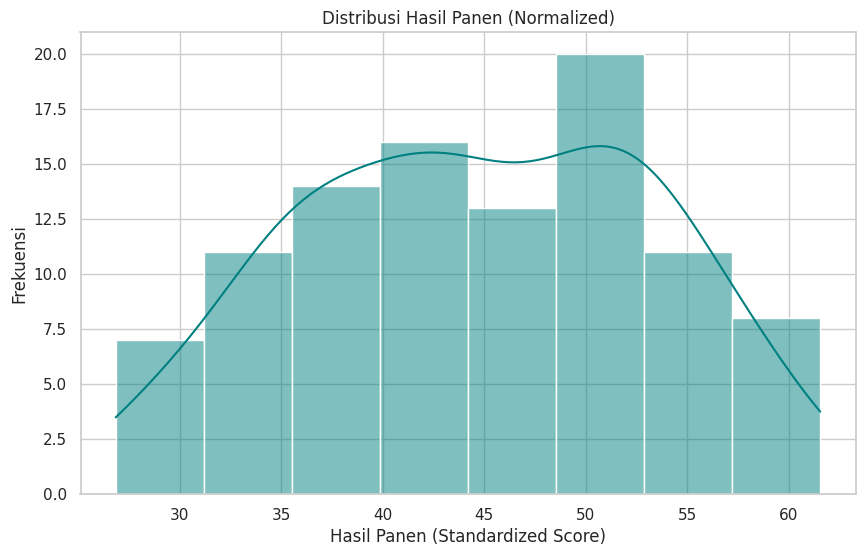

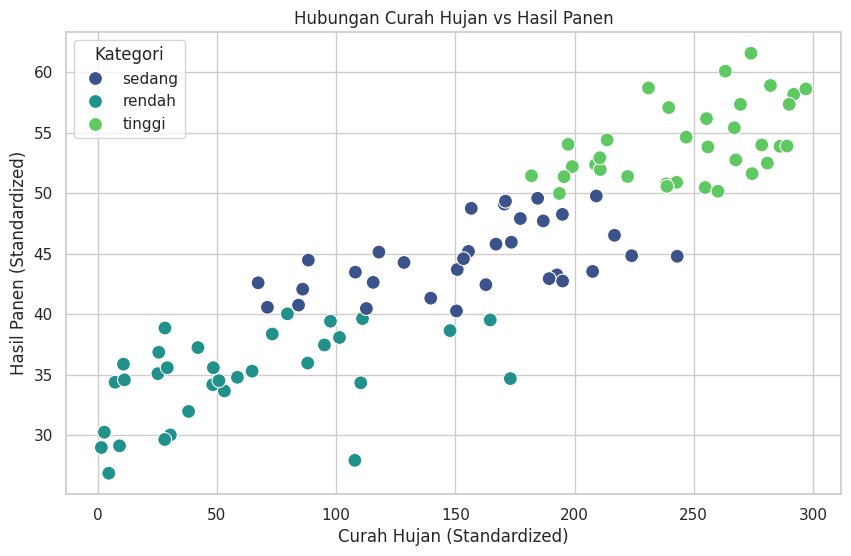

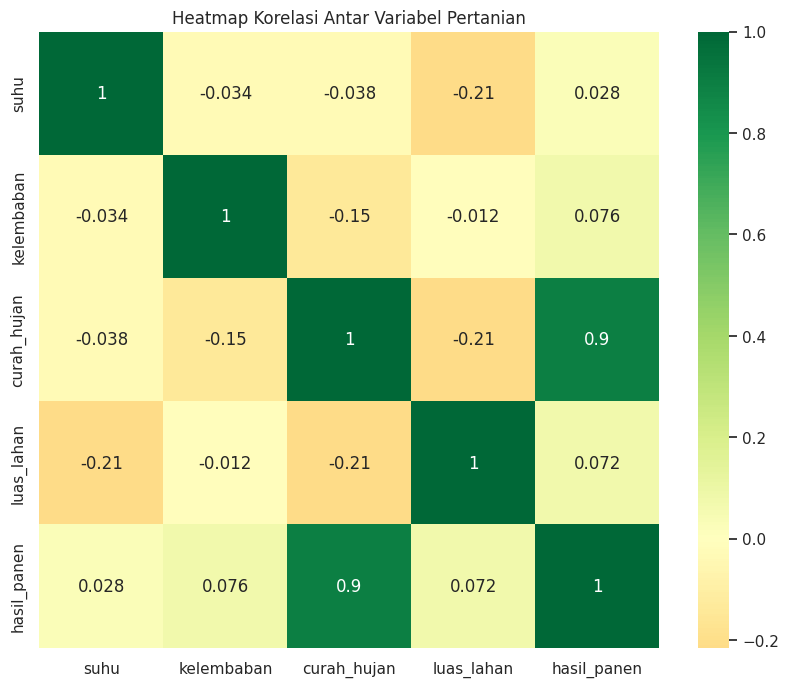

In [12]:
# Soal 5.1
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Histogram: Distribusi Hasil Panen
plt.figure(figsize=(10, 6))
sns.histplot(df['hasil_panen'], kde=True, color='teal')
plt.title('Distribusi Hasil Panen (Normalized)')
plt.xlabel('Hasil Panen (Standardized Score)')
plt.ylabel('Frekuensi')
plt.savefig('histogram_hasil_panen.png')
plt.show()

# 2. Scatter Plot: Curah Hujan vs Hasil Panen
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='curah_hujan', y='hasil_panen', hue='kategori_hasil', palette='viridis', s=100)
plt.title('Hubungan Curah Hujan vs Hasil Panen')
plt.xlabel('Curah Hujan (Standardized)')
plt.ylabel('Hasil Panen (Standardized)')
plt.legend(title='Kategori')
plt.savefig('scatter_hujan_panen.png')
plt.show() # Add this line to explicitly show the plot

# 3. Heatmap: Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Heatmap Korelasi Antar Variabel Pertanian')
plt.savefig('heatmap_korelasi_final.png')
plt.show()

5.2. Alasan Pemilihan Jenis Visualisasi
Pemilihan visualisasi didasarkan pada kebutuhan untuk memahami struktur data dari berbagai dimensi sebelum melakukan pemodelan tingkat lanjut. Histogram dipilih karena sangat efektif untuk membedah distribusi variabel tunggal, dalam hal ini hasil_panen, guna mendeteksi apakah terdapat pola pengelompokan alami atau keberadaan outliers yang dapat mengganggu performa model. Dengan melihat histogram, kita dapat menentukan apakah normalisasi yang dilakukan sebelumnya telah menghasilkan sebaran data yang lebih seimbang atau masih memerlukan transformasi tambahan agar distribusi lebih mendekati normal.

Selanjutnya, penggunaan Scatter Plot dan Heatmap bertujuan untuk memetakan hubungan antar variabel secara visual. Scatter Plot dipilih khusus untuk melihat interaksi bivariat antara curah_hujan dan hasil_panen karena kemampuannya menunjukkan tren linear dan kepadatan data secara mendetail. Sementara itu, Heatmap dipilih sebagai alat ringkasan korelasi seluruh fitur numerik secara simultan. Dengan menggunakan skala warna, Heatmap memudahkan identifikasi fitur yang paling berpengaruh (feature importance) terhadap target tanpa harus membaca tabel korelasi angka satu per satu, sehingga mempercepat pengambilan keputusan dalam proses seleksi fitur.

5.3. Interpretasi Hasil Visualisasi
Berdasarkan hasil visualisasi, ditemukan bahwa variabel curah_hujan merupakan faktor paling determinan dalam menentukan kategori hasil panen di dataset ini. Grafik Scatter Plot menunjukkan korelasi positif yang sangat kuat dan linear; hampir semua sampel dengan curah hujan tinggi berada di kategori 'tinggi', sementara curah hujan rendah secara konsisten berujung pada kategori 'rendah'. Hal ini didukung oleh Heatmap korelasi yang menunjukkan angka 0,90 pada hubungan kedua variabel tersebut, yang berarti strategi irigasi atau pemantauan debit air harus menjadi prioritas utama dalam manajemen pertanian ini.

Di sisi lain, visualisasi menunjukkan bahwa faktor fisik seperti luas_lahan dan faktor lingkungan lainnya seperti suhu serta kelembaban tidak memiliki pengaruh linear yang signifikan. Melalui histogram, terlihat bahwa distribusi hasil panen cukup bervariasi namun tetap terkumpul pada klaster-klaster kategori yang jelas, yang menjelaskan mengapa algoritma Decision Tree sebelumnya mampu mencapai akurasi hingga 100%. Secara keseluruhan, visualisasi ini menegaskan bahwa untuk meningkatkan hasil panen, fokus tidak perlu diarahkan pada perluasan lahan, melainkan pada optimalisasi variabel curah hujan atau ketersediaan air yang terbukti memiliki keterkaitan paling erat.